In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the required libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use("default")
sns.set_context("notebook")

# Import csv file

In [3]:
df = pd.read_csv("flim.csv")
df

,Unnamed: 0,SN,Movie,Worldwide,India Net,India Gross,Overseas,Budget,Verdict
0,0,1,Pathaan,10500000000,5240000000,6570000000,3920000000,2500000000,All Time Blockbuster
1,1,2,Baahubali 2 The Conclusion,17880000000,5100000000,14160000000,3710000000,2500000000,All Time Blockbuster
2,2,3,KGF Chapter 2,12080000000,4350000000,10000000000,2070000000,1000000000,All Time Blockbuster
3,3,4,Dangal,20700000000,3740000000,5350000000,15350000000,700000000,All Time Blockbuster
4,4,5,Sanju,5880000000,3420000000,4380000000,1500000000,1000000000,All Time Blockbuster
...,...,...,...,...,...,...,...,...,...
995,995,996,Nikamma,0,20000000,20000000,0,10000000,0
996,996,997,Saugandh,30000000,20000000,30000000,0,20000000,Average
997,997,998,Akaash Vani,30000000,20000000,20000000,0,100000000,Disaster
998,998,999,Zwigato,10000000,20000000,10000000,0,10000000,0


# Analyzing and cleaning data

In [4]:
df.shape # Numbers of raw and column

(1000, 9)

In [5]:
df.columns

Index(['Unnamed: 0', 'SN', 'Movie', 'Worldwide', 'India Net', 'India Gross',
       'Overseas', 'Budget', 'Verdict'],
      dtype='object')

In [6]:
df.drop(columns = ["Unnamed: 0"], inplace = True) # Drop unwanted column

In [7]:
df.info() # Column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SN           1000 non-null   int64 
 1   Movie        1000 non-null   object
 2   Worldwide    1000 non-null   int64 
 3   India Net    1000 non-null   int64 
 4   India Gross  1000 non-null   int64 
 5   Overseas     1000 non-null   int64 
 6   Budget       1000 non-null   int64 
 7   Verdict      1000 non-null   object
dtypes: int64(6), object(2)
memory usage: 62.6+ KB


In [8]:
df.isnull().sum() # See null values in data frame

SN             0
Movie          0
Worldwide      0
India Net      0
India Gross    0
Overseas       0
Budget         0
Verdict        0
dtype: int64

In [9]:
df.isnull().sum() * 100/len(df) # Percentage of null value

SN             0.0
Movie          0.0
Worldwide      0.0
India Net      0.0
India Gross    0.0
Overseas       0.0
Budget         0.0
Verdict        0.0
dtype: float64

In [10]:
df.drop_duplicates() # Drop duplicate values but it seen that dataframe doesnot contain any duplicates

,SN,Movie,Worldwide,India Net,India Gross,Overseas,Budget,Verdict
0,1,Pathaan,10500000000,5240000000,6570000000,3920000000,2500000000,All Time Blockbuster
1,2,Baahubali 2 The Conclusion,17880000000,5100000000,14160000000,3710000000,2500000000,All Time Blockbuster
2,3,KGF Chapter 2,12080000000,4350000000,10000000000,2070000000,1000000000,All Time Blockbuster
3,4,Dangal,20700000000,3740000000,5350000000,15350000000,700000000,All Time Blockbuster
4,5,Sanju,5880000000,3420000000,4380000000,1500000000,1000000000,All Time Blockbuster
...,...,...,...,...,...,...,...,...
995,996,Nikamma,0,20000000,20000000,0,10000000,0
996,997,Saugandh,30000000,20000000,30000000,0,20000000,Average
997,998,Akaash Vani,30000000,20000000,20000000,0,100000000,Disaster
998,999,Zwigato,10000000,20000000,10000000,0,10000000,0


In [11]:
df.describe()

,SN,Worldwide,India Net,India Gross,Overseas,Budget
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,500.500000,1.832870e+09,4.079600e+08,6.126900e+08,9.714300e+08,5.889000e+08
std,288.819436,1.049006e+10,5.783055e+08,9.814085e+08,8.596981e+09,2.101992e+09
min,1.000000,0.000000e+00,2.000000e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,250.750000,1.600000e+08,9.000000e+07,1.400000e+08,1.000000e+07,8.000000e+07
50%,500.500000,3.700000e+08,2.000000e+08,3.100000e+08,5.000000e+07,2.000000e+08
75%,750.250000,9.025000e+08,4.600000e+08,6.825000e+08,1.500000e+08,4.000000e+08
max,1000.000000,1.897000e+11,5.240000e+09,1.416000e+10,1.690200e+11,3.200000e+10


#  Outliers detection

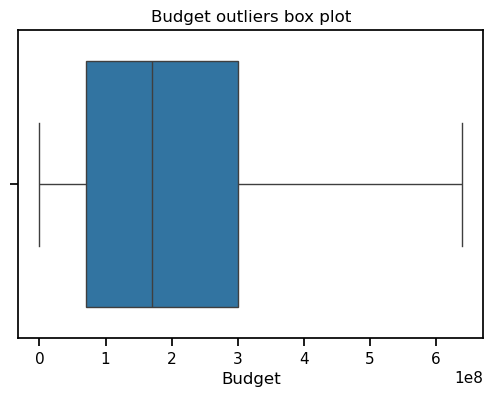

In [35]:
plt.figure (figsize = (6,4)) # Length and breath of box
sns.boxplot (x = df["Budget"]) # Type of diagram

plt.title("Budget outliers box plot") # Giving title to plot diagram
plt.show() # Function that shows plot diagram

# Interquartile range method

In [36]:
q1 = df["Budget"].quantile(0.25) # Quantile of q1
q3 = df["Budget"].quantile(0.75) # Quantile of q2
IQR = q3 - q1 # Formula

In [37]:
lowerlimit = q1 - 1.5 * IQR # Lower outlier will be considered anything under first quantile formula
upperlimit = q3 + 1.5 * IQR # upper outlier will be considered anything over third quantile formula

In [38]:
df = df[(df["Budget"] >= lowerlimit) & (df["Budget"] <= upperlimit)] # Condition for new output

In [39]:
df # Dataframe after removing the outliers

,SN,Movie,Worldwide,India Net,India Gross,Overseas,Budget,Verdict
11,12,Kabir Singh,3770000000,2780000000,3300000000,470000000,550000000,All Time Blockbuster
15,16,The Kashmir Files,3410000000,2520000000,2950000000,460000000,200000000,All Time Blockbuster
19,20,Drishyam 2,3420000000,2390000000,2820000000,590000000,500000000,All Time Blockbuster
27,28,Good Newwz,3160000000,2050000000,2420000000,740000000,600000000,Blockbuster
28,29,Mission Mangal,2900000000,2030000000,2360000000,540000000,400000000,Blockbuster
...,...,...,...,...,...,...,...,...
995,996,Nikamma,0,20000000,20000000,0,10000000,0
996,997,Saugandh,30000000,20000000,30000000,0,20000000,Average
997,998,Akaash Vani,30000000,20000000,20000000,0,100000000,Disaster
998,999,Zwigato,10000000,20000000,10000000,0,10000000,0


# 1. What is the number of movie aligned budget analysis?

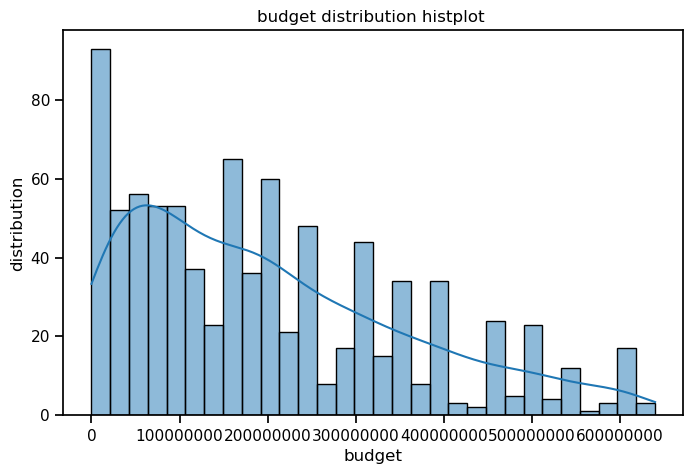

In [40]:
plt.figure(figsize = (8,5))
sns.histplot(df["Budget"],bins = 30, kde = True) # Import histplot
plt.ticklabel_format(style="plain",axis ='x')
plt.title("budget distribution histplot ")
plt.xlabel("budget")
plt.ylabel("distribution")
plt.show()

# 2. which movie has biggest average budget?

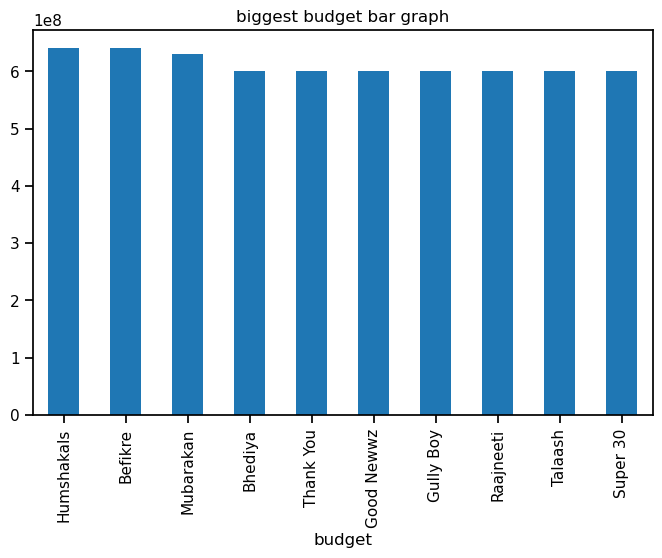

In [41]:
movie_budget = df.groupby("Movie")['Budget'].mean().sort_values(ascending = False).head(10)
movie_budget
plt.figure(figsize = (8,5))
movie_budget.plot(kind = 'bar')
plt.title("biggest budget bar graph")
plt.xlabel("budget")
plt.show()

# 3. which movie has highest box office overseas?

In [42]:
df["Movie"].nunique() # Gives number of unique values

849

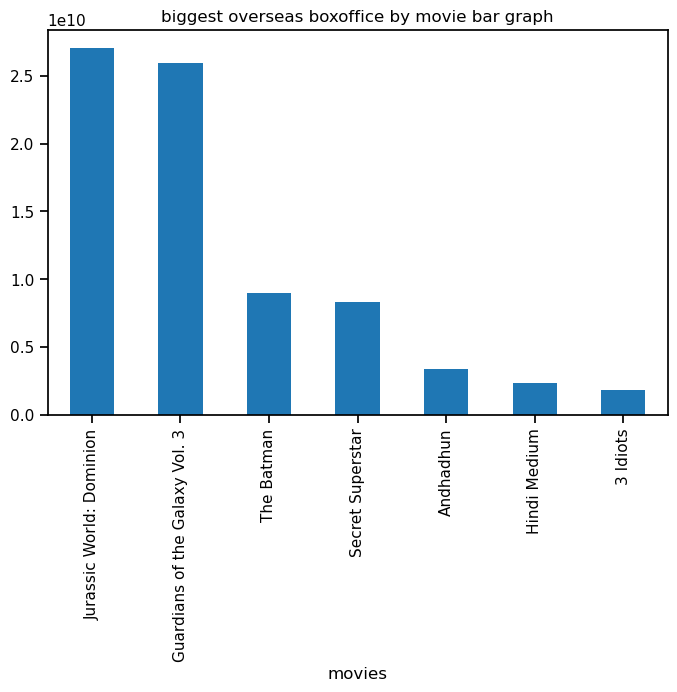

In [43]:
movie_seas = df.groupby("Movie")["Overseas"].mean().sort_values(ascending=False).head(7)
plt.figure(figsize = (8,5))
movie_seas.plot(kind = 'bar')
plt.title("biggest overseas boxoffice by movie bar graph")
plt.xlabel("movies")
plt.show()

# 4. Top 5 movies with highest and lowest box office in overseas?

In [44]:
top5 = movie_seas.sort_values(ascending=False).head(5)
top5

Movie
Jurassic World: Dominion          2.700000e+10
Guardians of the Galaxy Vol. 3    2.595000e+10
The Batman                        9.000000e+09
Secret Superstar                  8.310000e+09
Andhadhun                         3.430000e+09
Name: Overseas, dtype: float64

In [45]:
bottom5 = df.groupby("Movie")["Overseas"].mean().sort_values(ascending=True).head(5)
bottom5

Movie
Zwigato                     0.0
Traffic                     0.0
Gumraah                     0.0
Jalebi                      0.0
Lipstick Under My Burkha    0.0
Name: Overseas, dtype: float64

# 5. what is the most common verdict?

In [46]:
common_verdict = df["Verdict"].value_counts().head(10) # Valuecount list in desecnding order
common_verdict 

Verdict
Flop                    175
Hit                     169
Average                 121
SuperHit                 97
Disaster                 69
Blockbuster              55
Below Average            55
Above Average            54
0                        42
All Time Blockbuster     17
Name: count, dtype: int64

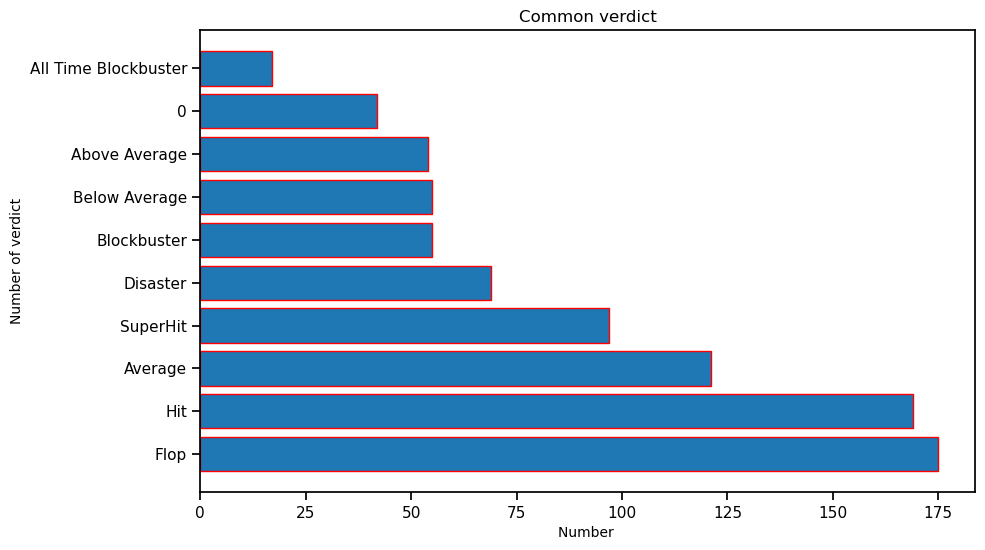

In [47]:
plt.figure(figsize = (10,6))
plt.barh(common_verdict.index, common_verdict.values, edgecolor = 'red')
plt.title("Common verdict")
plt.xlabel("Number ", fontsize = 10)
plt.ylabel("Number of verdict", fontsize = 10)
plt.show()

# 6. Check relationship between india gross and india net?

In [48]:
df["India Net"].corr(df["India Gross"]) # Check correaltion

0.9556193256135745

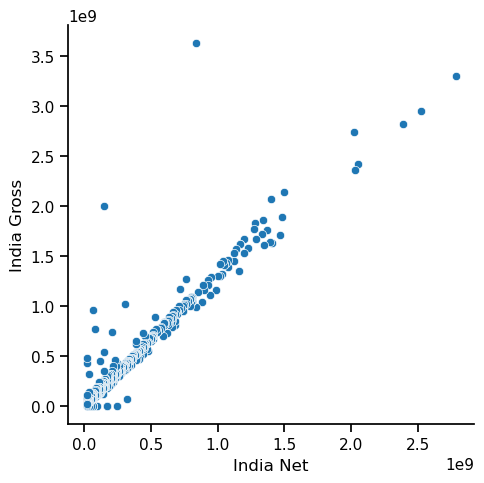

In [49]:
sns.relplot (x = "India Net", y = "India Gross",data = df)